# 1. Imports

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

pd.set_option("display.max_columns", None)

# 2. Load Data

In [2]:
DB_PATH = "../compliance_audit.db"

conn = sqlite3.connect(DB_PATH)

df = pd.read_sql_query(
    """
    SELECT *
    FROM audited_trades
    """,
    conn
)

print(df.shape)
df.head()

(351, 33)


,trade_id,trade_timestamp,client_age,client_income,risk_tolerance,investment_experience,investment_objective,investment_time_horizon,investment_type,investment_amount,advisor_id,advisor_experience,advisor_history_risk,advisor_rationale,advisor_notes,kyc_completeness,true_compliance,case_type,scenario_name,difficulty,severity_tier,expected_workflow_bucket,relevant_policies,primary_policy,compliance_probability,compliance_label,risk_score,confidence_score,escalation_level,priority_score,flag_reasons,retrieved_policies,retrieved_chunks
0,TRADE-1afa2bce,2026-05-15 06:44:10.923601,33,48278.0,High,Beginner,Growth,Long,ETFs,8428.72,ADV-035,Junior,Low,Discussed client's growth objective and select...,Detailed educational discussion completed. Cli...,Complete,1,Aligned Recommendation,Aligned Recommendation,Easy,Low,Auto_pass,[],,1.00,1,0.0,0.820,none,0.00,Client profile information may be incomplete o...,"[""POL-002-KYC"", ""POL-006-HIGH-RISK-PRODUCTS"", ...","[{""chunk_id"": ""POL-002-KYC_CH_002"", ""policy_id..."
1,TRADE-c2fdd74b,2026-05-27 19:17:11.908124,25,118563.0,High,Beginner,Growth,Medium,Mutual Funds,20146.55,ADV-011,Mid,Medium,Recommended allocation to Mutual Funds based o...,Trade increases exposure to existing position....,Complete,1,Aligned Recommendation,Aligned Recommendation,Easy,Low,Auto_pass,[],,1.00,1,0.0,0.820,none,0.00,Recommendation may not align with stated inves...,"[""POL-010-CLIENT-OBJECTIVE"", ""POL-001-SUITABIL...","[{""chunk_id"": ""POL-002-KYC_CH_002"", ""policy_id..."
2,TRADE-cd94b988,2026-06-12 01:34:38.713750,23,94797.0,High,Intermediate,Growth,Medium,ETFs,15186.62,ADV-025,Junior,Low,Discussed client's growth objective and select...,Detailed educational discussion completed. Cli...,Complete,1,Aligned Recommendation,Aligned Recommendation,Easy,Low,Auto_pass,[],,1.00,1,0.0,0.820,none,0.00,Recommendation may not align with stated inves...,"[""POL-010-CLIENT-OBJECTIVE"", ""POL-001-SUITABIL...","[{""chunk_id"": ""POL-002-KYC_CH_002"", ""policy_id..."
3,TRADE-c931a27b,2026-05-27 06:33:24.283466,38,117930.0,Low,Intermediate,Income,Short,Stocks,22384.72,ADV-024,Mid,Low,Recommended Stocks as part of a diversified as...,Client confirmed financial circumstances remai...,Complete,0,Suitability Violation,Aggressive Horizon,Easy,High,Priority,"[""POL-001-SUITABILITY"", ""POL-003-SURVEILLANCE""]",POL-001-SUITABILITY,0.40,0,55.0,0.895,queue,41.65,Client profile information may be incomplete o...,"[""POL-002-KYC"", ""POL-006-HIGH-RISK-PRODUCTS"", ...","[{""chunk_id"": ""POL-002-KYC_CH_002"", ""policy_id..."
4,TRADE-daab8537,2026-05-30 04:57:49.369301,30,67431.0,Medium,Beginner,Growth,Medium,Mutual Funds,7290.83,ADV-045,Mid,High,Position established in Mutual Funds to capita...,Trade increases concentration exposure and sho...,Uncertain,1,Risk Signal,High Risk Advisor,Hard,Medium,Queue,"[""POL-002-KYC"", ""POL-003-SURVEILLANCE""]",POL-002-KYC,0.75,0,20.0,0.680,none,0.00,Recommendation may not align with stated inves...,"[""POL-010-CLIENT-OBJECTIVE"", ""POL-001-SUITABIL...","[{""chunk_id"": ""POL-002-KYC_CH_002"", ""policy_id..."


# 3. Parse Stored Lists

In [3]:
LIST_COLUMNS = [
    "relevant_policies",
    "retrieved_policies"
]

for col in LIST_COLUMNS:
    df[col] = df[col].apply(ast.literal_eval)

df.head(1)

,trade_id,trade_timestamp,client_age,client_income,risk_tolerance,investment_experience,investment_objective,investment_time_horizon,investment_type,investment_amount,advisor_id,advisor_experience,advisor_history_risk,advisor_rationale,advisor_notes,kyc_completeness,true_compliance,case_type,scenario_name,difficulty,severity_tier,expected_workflow_bucket,relevant_policies,primary_policy,compliance_probability,compliance_label,risk_score,confidence_score,escalation_level,priority_score,flag_reasons,retrieved_policies,retrieved_chunks
0,TRADE-1afa2bce,2026-05-15 06:44:10.923601,33,48278.0,High,Beginner,Growth,Long,ETFs,8428.72,ADV-035,Junior,Low,Discussed client's growth objective and select...,Detailed educational discussion completed. Cli...,Complete,1,Aligned Recommendation,Aligned Recommendation,Easy,Low,Auto_pass,[],,1.0,1,0.0,0.82,none,0.0,Client profile information may be incomplete o...,"[POL-002-KYC, POL-006-HIGH-RISK-PRODUCTS, POL-...","[{""chunk_id"": ""POL-002-KYC_CH_002"", ""policy_id..."


# 4. Basic Dataset Summary

In [4]:
print(f"Cases: {len(df)}")

print("\nCompliance Distribution")
print(df["true_compliance"].value_counts())

print("\nWorkflow Distribution")
print(df["expected_workflow_bucket"].value_counts())

print("\nPredicted Workflow Distribution")
print(df["escalation_level"].value_counts())

Cases: 351

Compliance Distribution
true_compliance
1    217
0    134
Name: count, dtype: int64

Workflow Distribution
expected_workflow_bucket
Auto_pass    115
Queue        100
Priority      98
Urgent        38
Name: count, dtype: int64

Predicted Workflow Distribution
escalation_level
none      222
queue      72
urgent     57
Name: count, dtype: int64


In [ ]:
priority_df = df[df["expected_workflow_bucket"] == "Priority"]

print(priority_df["risk_score"].describe())
print(priority_df["compliance_probability"].describe())
print(priority_df["confidence_score"].describe())

count    98.000000
mean      0.819694
std       0.078717
min       0.685000
25%       0.730000
50%       0.815000
75%       0.895000
max       0.895000
Name: confidence_score, dtype: float64

# 5. Compliance Classification Accuracy

In [5]:
compliance_accuracy = accuracy_score(
    df["true_compliance"],
    df["compliance_label"]
)

print(f"Compliance Accuracy: {compliance_accuracy:.3f}")

Compliance Accuracy: 0.815


# 6. Compliance Confusion Matrix

In [6]:
cm = confusion_matrix(
    df["true_compliance"],
    df["compliance_label"]
)

pd.DataFrame(
    cm,
    index=["Actual Non-Compliant", "Actual Compliant"],
    columns=["Predicted Non-Compliant", "Predicted Compliant"]
)

,Predicted Non-Compliant,Predicted Compliant
Actual Non-Compliant,134,0
Actual Compliant,65,152


# 7. Classification Report

In [7]:
print(
    classification_report(
        df["true_compliance"],
        df["compliance_label"]
    )
)

              precision    recall  f1-score   support

           0       0.67      1.00      0.80       134
           1       1.00      0.70      0.82       217

    accuracy                           0.81       351
   macro avg       0.84      0.85      0.81       351
weighted avg       0.88      0.81      0.82       351



# 8. Map Workflow Buckets

In [8]:
WORKFLOW_MAPPING = {
    "none": "Auto_pass",
    "queue": "Queue",
    "priority": "Priority",
    "urgent": "Urgent"
}

df["predicted_workflow_bucket"] = (
    df["escalation_level"]
    .map(WORKFLOW_MAPPING)
)

# 9. Workflow Contingency Table

In [9]:
workflow_table = pd.crosstab(
    df["expected_workflow_bucket"],
    df["predicted_workflow_bucket"],
    margins=True
)

workflow_table

predicted_workflow_bucket,Auto_pass,Queue,Urgent,All
expected_workflow_bucket,,,,
Auto_pass,115,0,0,115
Priority,14,65,19,98
Queue,93,7,0,100
Urgent,0,0,38,38
All,222,72,57,351


# 9.1 Expected Queue Bucket Score Distributions

Expected Queue cases: 100

Risk Score Summary
count    100.000000
mean      18.850000
std        7.277161
min       10.000000
25%       15.000000
50%       15.000000
75%       25.000000
max       35.000000
Name: risk_score, dtype: float64

Confidence Score Summary
count    100.000000
mean       0.703800
std        0.045804
min        0.650000
25%        0.650000
50%        0.730000
75%        0.730000
max        0.895000
Name: confidence_score, dtype: float64

Compliance Probability Summary
count    100.000000
mean       0.844500
std        0.127306
min        0.550000
25%        0.750000
50%        0.800000
75%        1.000000
max        1.000000
Name: compliance_probability, dtype: float64

Queue Cases Below Risk Threshold
risk_score_below_35
True     93.0
False     7.0
Name: proportion, dtype: float64

Queue Cases Below Confidence Threshold
confidence_below_60
False    100.0
Name: proportion, dtype: float64


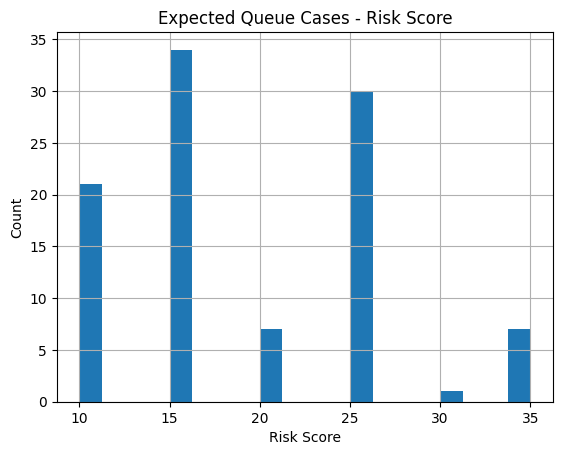

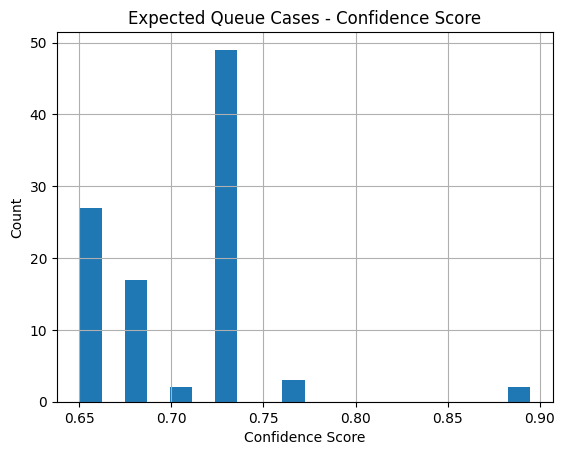

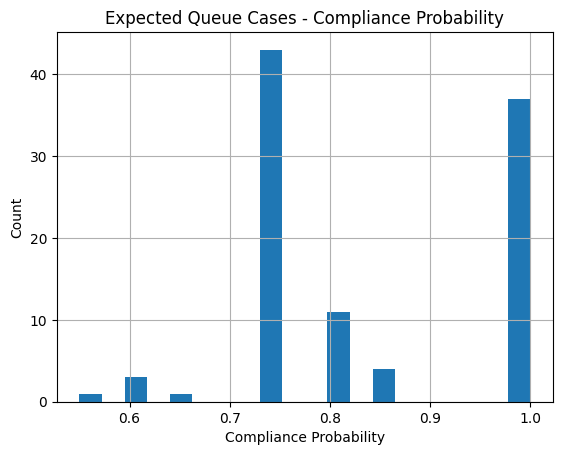

In [10]:
queue_df = df[
    df["expected_workflow_bucket"] == "Queue"
].copy()

print(f"Expected Queue cases: {len(queue_df)}")

print("\nRisk Score Summary")
print(queue_df["risk_score"].describe())

print("\nConfidence Score Summary")
print(queue_df["confidence_score"].describe())

print("\nCompliance Probability Summary")
print(queue_df["compliance_probability"].describe())

queue_df["risk_score_below_35"] = (
    queue_df["risk_score"] < 35
)

queue_df["confidence_below_60"] = (
    queue_df["confidence_score"] < 0.60
)

print("\nQueue Cases Below Risk Threshold")
print(
    queue_df["risk_score_below_35"]
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
)

print("\nQueue Cases Below Confidence Threshold")
print(
    queue_df["confidence_below_60"]
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
)

pd.crosstab(
    queue_df["expected_workflow_bucket"],
    queue_df["escalation_level"],
    margins=True
)

queue_df["risk_score"].hist(bins=20)
plt.title("Expected Queue Cases - Risk Score")
plt.xlabel("Risk Score")
plt.ylabel("Count")
plt.show()

queue_df["confidence_score"].hist(bins=20)
plt.title("Expected Queue Cases - Confidence Score")
plt.xlabel("Confidence Score")
plt.ylabel("Count")
plt.show()

queue_df["compliance_probability"].hist(bins=20)
plt.title("Expected Queue Cases - Compliance Probability")
plt.xlabel("Compliance Probability")
plt.ylabel("Count")
plt.show()

# 9.2 Expected Urgent Bucket Score Distributions

In [11]:
urgent_df = df[
    df["expected_workflow_bucket"] == "Urgent"
].copy()

print(f"Expected Urgent cases: {len(urgent_df)}")

urgent_df["risk_ge_80"] = (
    urgent_df["risk_score"] >= 80
)

urgent_df["risk_ge_65"] = (
    urgent_df["risk_score"] >= 65
)

print("\nRisk >= 80")
print(
    urgent_df["risk_ge_80"]
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
)

print("\nRisk >= 65")
print(
    urgent_df["risk_ge_65"]
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
)

print(
    urgent_df["risk_score"]
    .describe()
)

print(
    pd.crosstab(
        urgent_df["expected_workflow_bucket"],
        urgent_df["escalation_level"],
        margins=True
    )
)

urgent_df[
    [
        "risk_score",
        "confidence_score",
        "compliance_probability",
        "escalation_level"
    ]
].sort_values("risk_score").head(30)

Expected Urgent cases: 38

Risk >= 80
risk_ge_80
True     94.7
False     5.3
Name: proportion, dtype: float64

Risk >= 65
risk_ge_65
True    100.0
Name: proportion, dtype: float64
count     38.000000
mean      93.815789
std        9.475018
min       70.000000
25%       95.000000
50%      100.000000
75%      100.000000
max      100.000000
Name: risk_score, dtype: float64
escalation_level          urgent  All
expected_workflow_bucket             
Urgent                        38   38
All                           38   38


,risk_score,confidence_score,compliance_probability,escalation_level
104,70.0,0.94,0.1,urgent
146,70.0,0.94,0.1,urgent
68,80.0,0.94,0.0,urgent
42,80.0,0.94,0.0,urgent
191,80.0,0.94,0.0,urgent
188,80.0,0.94,0.0,urgent
124,80.0,0.94,0.0,urgent
249,80.0,0.94,0.1,urgent
291,80.0,0.86,0.0,urgent
243,95.0,0.94,0.0,urgent


In [12]:
urgent_df.groupby("scenario_name").size().sort_values(ascending=False)

scenario_name
Compound Violation         21
Insufficient Experience    12
Retiree Options             5
dtype: int64

In [13]:
pd.crosstab(
    df["scenario_name"],
    df["escalation_level"],
    margins=True
)

escalation_level,none,queue,urgent,All
scenario_name,,,,
Aggressive Horizon,5,4,4,13
Aggressive Objective,12,5,1,18
Aligned Recommendation,95,0,0,95
Compound Violation,0,0,21,21
Conflicting Signals,29,0,0,29
High Risk Advisor,6,0,0,6
Insufficient Experience,14,8,12,34
KYC Missing,0,23,0,23
Low Priority Exception,17,0,0,17


In [14]:
pd.crosstab(
    df["scenario_name"],
    df["expected_workflow_bucket"],
    margins=True
)

expected_workflow_bucket,Auto_pass,Priority,Queue,Urgent,All
scenario_name,,,,,
Aggressive Horizon,0,6,7,0,13
Aggressive Objective,0,6,12,0,18
Aligned Recommendation,85,0,10,0,95
Compound Violation,0,0,0,21,21
Conflicting Signals,26,0,3,0,29
High Risk Advisor,4,0,2,0,6
Insufficient Experience,0,22,0,12,34
KYC Missing,0,23,0,0,23
Low Priority Exception,0,0,17,0,17


# 10. Workflow Accuracy

In [15]:
workflow_accuracy = (
    df["expected_workflow_bucket"]
    ==
    df["predicted_workflow_bucket"]
).mean()

print(
    f"Workflow Accuracy: "
    f"{workflow_accuracy:.3f}"
)

Workflow Accuracy: 0.456


# 11. Primary Policy Retrieved Check

In [16]:
retrieval_df = df[
    df["relevant_policies"]
    .apply(len)
    > 0
]

retrieval_df["primary_policy_retrieved"] = retrieval_df.apply(
    lambda row:
        row["primary_policy"]
        in row["retrieved_policies"],
    axis=1
)

# 12. Primary Policy Recall

In [17]:
primary_policy_recall = (
    retrieval_df["primary_policy_retrieved"]
    .mean()
)

print(
    f"Primary Policy Recall: "
    f"{primary_policy_recall:.3f}"
)

Primary Policy Recall: 0.776


# 13. Relevant Policy Retrieval Check

In [18]:
def any_relevant_policy_retrieved(row):

    retrieved = set(row["retrieved_policies"])
    relevant = set(row["relevant_policies"])

    return len(
        retrieved & relevant
    ) > 0


retrieval_df["any_relevant_policy_retrieved"] = (
    retrieval_df.apply(
        any_relevant_policy_retrieved,
        axis=1
    )
)

# 14. Any Relevant Policy Recall

In [19]:
any_relevant_policy_recall = (
    retrieval_df["any_relevant_policy_retrieved"]
    .mean()
)

print(
    f"Any Relevant Policy Recall: "
    f"{any_relevant_policy_recall:.3f}"
)

Any Relevant Policy Recall: 0.920


# 15. Retrieval Precision @k

In [20]:
def precision_at_k(row):

    retrieved = set(row["retrieved_policies"])
    relevant = set(row["relevant_policies"])

    if len(retrieved) == 0:
        return 0

    return (
        len(retrieved & relevant)
        /
        len(retrieved)
    )


retrieval_df["precision_at_k"] = (
    retrieval_df.apply(
        precision_at_k,
        axis=1
    )
)

print(
    f"Precision@k: "
    f"{retrieval_df['precision_at_k'].mean():.3f}"
)

Precision@k: 0.353


# 16. Retrieval Recall @k

In [21]:
def recall_at_k(row):

    retrieved = set(row["retrieved_policies"])
    relevant = set(row["relevant_policies"])

    if len(relevant) == 0:
        return np.nan

    return (
        len(retrieved & relevant)
        /
        len(relevant)
    )

retrieval_df["recall_at_k"] = (
    retrieval_df.apply(
        recall_at_k,
        axis=1
    )
)

print(
    f"Recall@k: "
    f"{retrieval_df['recall_at_k'].mean():.3f}"
)

Recall@k: 0.601


# 17. Retrieval Failure Breakdown

In [22]:
retrieval_df["num_relevant_retrieved"] = retrieval_df.apply(
    lambda row:
        len(
            set(row["retrieved_policies"])
            &
            set(row["relevant_policies"])
        ),
    axis=1
)

retrieval_df["num_relevant_retrieved"].value_counts().sort_index()

num_relevant_retrieved
0     24
1    133
2     93
3     13
4     32
5      4
Name: count, dtype: int64

# 18. Retrieval Diagnostic Table

In [23]:
pd.crosstab(
    retrieval_df["primary_policy_retrieved"],
    retrieval_df["any_relevant_policy_retrieved"],
    margins=True
)

any_relevant_policy_retrieved,False,True,All
primary_policy_retrieved,,,
False,24,43,67
True,0,232,232
All,24,275,299


# 19. Severity Tier Diagnostics

In [24]:
severity_summary = (
    retrieval_df.groupby("severity_tier")
      .agg({
          "primary_policy_retrieved": "mean",
          "precision_at_k": "mean",
          "recall_at_k": "mean",
          "true_compliance": "count"
      })
      .rename(
          columns={
              "true_compliance":
                  "case_count"
          }
      )
)

severity_summary

,primary_policy_retrieved,precision_at_k,recall_at_k,case_count
severity_tier,,,,
High,0.746269,0.477985,0.582392,134
Low,0.904762,0.230159,0.851852,63
Medium,0.735294,0.263725,0.469118,102


# 20. Final Summary

In [25]:
summary = pd.DataFrame({
    "Metric": [
        "Compliance Accuracy",
        "Workflow Accuracy",
        "Total Case Count",
        "Primary Policy Recall",
        "Any Relevant Policy Retrieved",
        "Precision@k",
        "Recall@k",
        "Retrieval Case Count"
    ],
    "Value": [
        compliance_accuracy,
        workflow_accuracy,
        len(df),
        primary_policy_recall,
        any_relevant_policy_recall,
        retrieval_df["precision_at_k"].mean(),
        retrieval_df["recall_at_k"].mean(),
        retrieval_df.shape[0]
    ]
})

summary

,Metric,Value
0,Compliance Accuracy,0.814815
1,Workflow Accuracy,0.455840
2,Total Case Count,351.000000
3,Primary Policy Recall,0.775920
4,Any Relevant Policy Retrieved,0.919732
5,Precision@k,0.352676
6,Recall@k,0.600526
7,Retrieval Case Count,299.000000
